Research question 

To what extent are rural communities able to achieve “green growth” in British Columbia, as measured by a decoupling of growth in wellbeing from the growth in GHG emissions? 

Scope 

Timeframe: 2006 (extrapolated) – 2021 

Emissions scope: CO2e for utilities of residential and small and medium indistry, on-road transportation, and large facilities

todos: 
1. manually add municipal boundaries to the shapefile of municipal boundaries
    a. find out municipalities not represented in current shape file
    b. open QGIS and add basemap from open streetmaps
    c. manually add polygons and assign the names of the municipalities to those polygons
2. resolve inconsistencies with northern rockies district, or resolve whether it should be removed from the analysis
3. add sechelt indian government to data analysis
4. assign industrial emissions to nearest (nerest three?) municipalities (or to nearest most populated?) using latitude and longitude

In [1]:
#import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [2]:
#load the community emissions dataset as csv file
utility_emissions = pd.read_csv('../data/raw/bc_utilities_energy_and_emissions.csv')

#replace W's from emissions in wood with 0
utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'].replace('W', 0)

# Display the first few rows of the utility emissions dataset
utility_emissions.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,"538,127,236","48,760","6,188",NaN
1,2022,BC Hydro,11080,1005923,Alberni-Clayoquot,9000000,ELEC,kWh,Res,"226,116,611","17,311","2,600",NaN
2,2022,BC Hydro,11080,2005923,Alberni-Clayoquot Unincorporated Areas,1005923,ELEC,kWh,Res,"79,348,847","5,601",912,NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,"3,775,260",275,43,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,"14,323,873",773,165,NaN


In [3]:
# load the transportation emissions dataset as csv file
transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')
transportation_emissions.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_3083/1375076493.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
4,2005951,Bulkley-Nechako Unincorporated Areas,1005951,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.11,1142.083256,573.325795,0.778630,NaN


In [4]:
# load the industrial emissions dataset as csv file
industrial_emissions = pd.read_csv('../data/raw/bc_industrial_facility_public_report_summary_raw_data.csv')
industrial_emissions.head()


,Reporting Year,Company Name,Facility Name,Primary Activity NAICS Code & Description,Facility Type,Latitude,Longitude,Regional District,CO2 fossil combustion,CO2 biomass combustion,...,SF6 FVPW,CO2 fossil total,CO2 biomass total,CH4 total,N2O total,HFCs total,PFCs total,SF6 total,Grand total (tCO2e),Verification Body
0,2012.0,Aitken Creek Gas Storage ULC,Aitken Creek Gas Storage ULC,211110--Oil and gas extraction (except oil sands),LFO,56.96,-121.920,British Columbia,"44,706.60",NaN,...,NaN,"44,710.58",NaN,"7,396.69",181.26,NaN,NaN,NaN,"52,288.53",SNC Lavalin Environment
1,2012.0,Alliance Pipeline Ltd.,"BC Aggregated Facilities (E<= 1,000t CO2e each)",486210--Pipeline Transportation of Natural Gas,Other Facilities,56.18,-120.607,British Columbia,258.37,NaN,...,NaN,259.30,NaN,"1,127.15",1.25,NaN,NaN,NaN,"1,387.70",Refer to LFO Report
2,2012.0,Alliance Pipeline Ltd.,BC Pipeline System (LFO),486210--Pipeline Transportation of Natural Gas,LFO,56.18,-120.607,British Columbia,"22,877.11",NaN,...,NaN,"22,878.66",NaN,"2,939.10",153.17,NaN,NaN,NaN,"25,970.92",KPMG Performance Registrar Inc.
3,2012.0,Alliance Pipeline Ltd.,Taylor Compressor Station,486210--Pipeline Transportation of Natural Gas,Large Facility,56.18,-120.607,British Columbia,"22,618.74",NaN,...,NaN,"22,619.36",NaN,"1,811.95",151.92,NaN,NaN,NaN,"24,583.23",Refer to LFO Report
4,2012.0,AltaGas Ltd.,ALA BC L_c,211110--Oil and gas extraction (except oil sands),Other Facilities,56.15,-120.670,British Columbia,88.93,NaN,...,NaN,90.87,NaN,"4,180.91",NaN,NaN,NaN,NaN,"4,271.78",Refer to LFO Report


To add industrial emissions:
1. convert lat and lon of each industry to points that can fall within the area of the municipal boundaries
2. assign the municipality name to each industry in the industries dataset (creating a new column to hold the municipality names in the industry dataset)
3. sum up the emissions of all industries within each municipality area and assign total emissions to that municipality in a new dataset
4. change the naming of municipalities in the shape file to match the naming of the other emissions datasets, so that we can aggregate these emissions

In [5]:
#Create point geometries from latitude and longitude in the industrial emissions dataset
geometry = [Point(xy) for xy in zip(industrial_emissions['Longitude'],industrial_emissions['Latitude'])]
#Create a GeoDataFrame for industrial emissions using the point geometries
gdf_industrial = gpd.GeoDataFrame(industrial_emissions, geometry = geometry, crs = 'EPSG:4326')
# Display the first few rows of the industrial emissions GeoDataFrame
gdf_industrial.head()

,Reporting Year,Company Name,Facility Name,Primary Activity NAICS Code & Description,Facility Type,Latitude,Longitude,Regional District,CO2 fossil combustion,CO2 biomass combustion,...,CO2 fossil total,CO2 biomass total,CH4 total,N2O total,HFCs total,PFCs total,SF6 total,Grand total (tCO2e),Verification Body,geometry
0,2012.0,Aitken Creek Gas Storage ULC,Aitken Creek Gas Storage ULC,211110--Oil and gas extraction (except oil sands),LFO,56.96,-121.920,British Columbia,"44,706.60",NaN,...,"44,710.58",NaN,"7,396.69",181.26,NaN,NaN,NaN,"52,288.53",SNC Lavalin Environment,POINT (-121.92000 56.96000)
1,2012.0,Alliance Pipeline Ltd.,"BC Aggregated Facilities (E<= 1,000t CO2e each)",486210--Pipeline Transportation of Natural Gas,Other Facilities,56.18,-120.607,British Columbia,258.37,NaN,...,259.30,NaN,"1,127.15",1.25,NaN,NaN,NaN,"1,387.70",Refer to LFO Report,POINT (-120.60700 56.18000)
2,2012.0,Alliance Pipeline Ltd.,BC Pipeline System (LFO),486210--Pipeline Transportation of Natural Gas,LFO,56.18,-120.607,British Columbia,"22,877.11",NaN,...,"22,878.66",NaN,"2,939.10",153.17,NaN,NaN,NaN,"25,970.92",KPMG Performance Registrar Inc.,POINT (-120.60700 56.18000)
3,2012.0,Alliance Pipeline Ltd.,Taylor Compressor Station,486210--Pipeline Transportation of Natural Gas,Large Facility,56.18,-120.607,British Columbia,"22,618.74",NaN,...,"22,619.36",NaN,"1,811.95",151.92,NaN,NaN,NaN,"24,583.23",Refer to LFO Report,POINT (-120.60700 56.18000)
4,2012.0,AltaGas Ltd.,ALA BC L_c,211110--Oil and gas extraction (except oil sands),Other Facilities,56.15,-120.670,British Columbia,88.93,NaN,...,90.87,NaN,"4,180.91",NaN,NaN,NaN,NaN,"4,271.78",Refer to LFO Report,POINT (-120.67000 56.15000)


In [6]:
#Load municipal boundaries shapefile
gdf_municipal_boundaries = gpd.read_file('../data/raw/BC_municipal_boundaries/all_municipal_boundaries_BC.shp')

#display the first few rows of the municipal boundaries GeoDataFrame
gdf_municipal_boundaries.tail()


,AA_ID,AA_NAME,ABRVN,BDY_TYPE,AA_TYPE,AA_PARENT,CHNG_ORG,UPT_TYPE,UPT_DATE,MAP_STATUS,...,IMAGE_URL,AFCTD_AREA,AREA_SQM,LENGTH_M,SHAPE,OBEJCTID,id,layer,path,geometry
156,313.0,City of Nanaimo,Nanaimo,LGL,Municipality,Regional District of Nanaimo,MUNI,E,None,Not Appended,...,None,None,1.228478e+08,78827.8582,None,67061.0,NaN,ABMS_LAA_polygon,/Users/aloy/Documents/Grad school/Thesis/Data/...,"POLYGON ((-123.97486 49.13405, -123.97922 49.1..."
157,314.0,Town of Qualicum Beach,Qualicum Beach,LGL,Municipality,Regional District of Nanaimo,MUNI,E,None,Not Appended,...,None,None,2.006755e+07,28681.7243,None,67062.0,NaN,ABMS_LAA_polygon,/Users/aloy/Documents/Grad school/Thesis/Data/...,"POLYGON ((-124.38394 49.34647, -124.38425 49.3..."
158,323.0,City of Powell River,Powell River,LGL,Municipality,qathet Regional District,MUNI,E,20130405,Not Appended,...,None,None,4.153276e+07,39257.6198,None,67071.0,NaN,ABMS_LAA_polygon,/Users/aloy/Documents/Grad school/Thesis/Data/...,"POLYGON ((-124.56638 49.90410, -124.56356 49.9..."
159,NaN,Colwood,None,None,Municipality,None,None,None,None,None,...,None,None,1.760000e+07,NaN,None,NaN,0.0,ABMS_LAA_polygon,/Users/aloy/Documents/Grad school/Thesis/Data/...,"POLYGON ((-123.44850 48.44903, -123.44564 48.4..."
160,NaN,Sooke,None,None,Municipality,None,None,None,None,None,...,None,None,5.660000e+07,NaN,None,NaN,0.0,ABMS_LAA_polygon,/Users/aloy/Documents/Grad school/Thesis/Data/...,"POLYGON ((-123.78703 48.36530, -123.72996 48.4..."


In [7]:
#print(gdf_municipal_boundaries[gdf_municipal_boundaries['AA_NAME'] =='Northern Rockies Regional Municipality'])

In [8]:
#Ensure the boundaries and industrial emissions data are in the same coordinate reference system (CRS)
gdf_industrial = gdf_industrial.to_crs(gdf_municipal_boundaries.crs)
print("Valid (True) or Invalid (False) geometries in municipalities boundaries shape files:", gdf_municipal_boundaries.geometry.is_valid.value_counts())

Valid (True) or Invalid (False) geometries in municipalities boundaries shape files: True    161
Name: count, dtype: int64


In [9]:
#Perform the spatial join
print("Performing spatial join...")
gdf_industrial_with_munic = gpd.sjoin(gdf_industrial, gdf_municipal_boundaries, 
                                     how='left', predicate='within')

gdf_industrial_with_munic.head()
#save the joined data to a new CSV file
gdf_industrial_with_munic.to_csv('../data/processed/industrial_emissions_with_municipal_boundaries.csv', index=False)


Performing spatial join...


In [10]:
#count the number of industrial facilities in each municipality
industrial_facilities_count = gdf_industrial_with_munic.groupby('AA_NAME')['Facility Name'].count().reset_index()
industrial_facilities_count.rename(columns={'Facility Name': 'Industrial Facility Count'}, inplace=True)
#print the first few rows of the industrial facilities count
print(industrial_facilities_count)

                                              AA_NAME  \
0                                     City of Burnaby   
1                              City of Campbell River   
2                                   City of Castlegar   
3                                  City of Chilliwack   
4                                   City of Coquitlam   
5                                       City of Delta   
6                                City of Fort St John   
7                                 City of Grand Forks   
8                                    City of Kamloops   
9                                    City of Langford   
10                                    City of Merritt   
11                                    City of Nanaimo   
12                            City of New Westminster   
13                               City of Port Alberni   
14                                 City of Port Moody   
15                               City of Powell River   
16                             

In [11]:
# Check the results
print(f"Original industrial facilities: {len(gdf_industrial)}")
print(f"Facilities after spatial join: {len(gdf_industrial_with_munic)}")

# Check for facilities that didn't match any municipality
unmatched = gdf_industrial_with_munic[gdf_industrial_with_munic['AA_NAME'].isna()]
print(f"Unmatched facilities: {len(unmatched)}")

if len(unmatched) > 0:
    print("\nSample of unmatched facilities:")
    print(unmatched[['Latitude', 'Longitude']].head(5000))

Original industrial facilities: 7923
Facilities after spatial join: 7923
Unmatched facilities: 5767

Sample of unmatched facilities:
      Latitude  Longitude
0        56.96   -121.920
1        56.18   -120.607
2        56.18   -120.607
3        56.18   -120.607
6        56.32   -121.000
...        ...        ...
6862     56.30   -120.230
6863     56.30   -120.230
6864     48.00   -114.000
6865     57.45   -122.050
6868     57.36   -121.991

[5000 rows x 2 columns]


In [12]:
#Group by municipality and sum the emissions
# Remove commas from the values, then convert to numeric
gdf_industrial_with_munic['Grand total (tCO2e)'] = gdf_industrial_with_munic['Grand total (tCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
gdf_industrial_with_munic['Grand total (tCO2e)'] = pd.to_numeric(gdf_industrial_with_munic['Grand total (tCO2e)'], errors='coerce').fillna(0)

industrial_total_munic = gdf_industrial_with_munic.groupby(['Reporting Year','AA_NAME'])['Grand total (tCO2e)'].sum().reset_index()

# Rename for clarity
industrial_total_munic.rename(columns={'Grand total (tCO2e)': 'Total municipal large industrial emissions (tCO2e)'}, inplace=True)
#print unique municipalities
print("Unique municipalities in the industrial emissions data:")
print(industrial_total_munic['AA_NAME'].unique())

Unique municipalities in the industrial emissions data:
['City of Burnaby' 'City of Campbell River' 'City of Coquitlam'
 'City of Delta' 'City of Fort St John' 'City of Kamloops'
 'City of Langford' 'City of Merritt' 'City of Nanaimo'
 'City of Port Alberni' 'City of Port Moody' 'City of Powell River'
 'City of Prince George' 'City of Quesnel' 'City of Revelstoke'
 'City of Richmond' 'City of Surrey' 'City of Trail' 'City of Vancouver'
 'City of Williams Lake' 'District of Elkford' 'District of Fort St James'
 'District of Mackenzie' 'District of Sparwood' 'District of Taylor'
 'District of Tumbler Ridge' 'District of Vanderhoof'
 'Northern Rockies Regional Municipality'
 'The Corporation of the City of Dawson Creek'
 'The Corporation of the City of Victoria'
 'The Corporation of the District of Coldstream'
 'The Corporation of the District of North Cowichan'
 'The Corporation of the District of North Vancouver'
 'The Corporation of the District of Saanich'
 'The Corporation of the Tow

In [13]:
#list of regional districts including typos in datasets
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Greater Vancouver",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Stikine",
    "Sitkine",
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Comox Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Greater Vancouver Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Northern Rockies Unincorporated Areas", #check if there are variations to this, like Northern Rockies Regional Municipality Unincorporated Areas
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sitkine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]
province = ["British Columbia"]

Indigenous= ["Sechelt IGD", "Sechelt Ind Gov Dist (Part-Powell River)"]
 
outliers = ["Northern Rockies Regional Municipality","Northern Rockies RD", "Northern Rockies"]

#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_buildings_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

In [14]:
#remove "The Corporation of the District of" from municipality names
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('The Corporation of the District of ', '')
#remove "The Corporation of the City of" from municipality names
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('The Corporation of the City of ', '')
#make "The Corporation of the Township of Langley" just "Langley Township"
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('The Corporation of the Township of Langley', 'Langley Township')
#remove "The Corporation of the Township of" from municipality names
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('The Corporation of the Township of ', '')
#remove "Village of" from municipality names
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('Village of ', '')
#remove "City of" from municipality names
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('City of ', '')
#remove "District of" from municipality names
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('District of ', '')
#make "Fort St John" -> "Fort St. John"
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('Fort St John', 'Fort St. John')
#make "Fort St James" -> "Fort St. James"
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('Fort St James', 'Fort St. James')

#make "Northern Rockies Regional Municipality" -> "Northern Rockies"
industrial_total_munic['AA_NAME'] = industrial_total_munic['AA_NAME'].str.replace('Northern Rockies Regional Municipality', 'Northern Rockies')

#select municipalities from the industry emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~industrial_total_munic['AA_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
industry_df = industrial_total_munic[mask]

#print unique municipalities
print("Unique municipalities in the industrial emissions data:")
print(industry_df['AA_NAME'].unique())
print(industry_df)
#check if each year have the same number of municipalities
years = industry_df['Reporting Year'].unique()
for year in years:
    municipalities_in_year = industry_df[industry_df['Reporting Year'] == year]['AA_NAME'].unique()
    print(f"Year {year} has {len(municipalities_in_year)} municipalities: {municipalities_in_year}")

#save the industrial emissions data to a new CSV file
industry_df.to_csv('../data/processed/industrial_emissions_municipalities.csv', index=False)

Unique municipalities in the industrial emissions data:
['Burnaby' 'Campbell River' 'Coquitlam' 'Delta' 'Fort St. John' 'Kamloops'
 'Langford' 'Merritt' 'Nanaimo' 'Port Alberni' 'Port Moody' 'Powell River'
 'Prince George' 'Quesnel' 'Revelstoke' 'Richmond' 'Surrey' 'Trail'
 'Vancouver' 'Williams Lake' 'Elkford' 'Fort St. James' 'Mackenzie'
 'Sparwood' 'Taylor' 'Tumbler Ridge' 'Vanderhoof' 'Northern Rockies'
 'Dawson Creek' 'Victoria' 'Coldstream' 'North Cowichan' 'North Vancouver'
 'Saanich' 'Langley Township' 'Town of Princeton' 'Masset' 'Grand Forks'
 'Hudsons Hope' 'Logan Lake' 'Cache Creek' 'New Westminster' 'Kitimat'
 'Port Alice' 'Salmon Arm' 'Chetwynd' 'Chilliwack' 'Houston'
 'Spallumcheen' 'Castlegar' 'Prince Rupert' 'Port Edward' 'Terrace' 'Hope']
     Reporting Year            AA_NAME  \
0            2012.0            Burnaby   
1            2012.0     Campbell River   
2            2012.0          Coquitlam   
3            2012.0              Delta   
4            2012.0    

In [15]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~utility_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
utility_df = utility_emissions[mask]
print(utility_df['ORG_NAME'].unique())
utility_df.head()

['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Central Saanich' 'Chase' 'Chetwynd'
 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood' 'Comox'
 'Coquitlam' 'Courtenay' 'Cranbrook' 'Cumberland' 'Dawson Creek' 'Delta'
 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie' 'Fort St. James'
 'Fort St. John' 'Fraser Lake' 'Gibsons' 'Gold River' 'Golden' 'Granisle'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kelowna' 'Kent' 'Kimberley'
 'Kitimat' 'Ladysmith' 'Lake Country' 'Lake Cowichan' 'Langford'
 'Langley City' 'Langley Township' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Mission' 'Nakusp' 'Nanaimo' 'New Denver'
 'New Hazelton' 'North Cowichan' 'North Saanich' 'North Vancouver City'
 'North Vancouver District' 'Nort

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,"538,127,236","48,760","6,188",NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,"3,775,260",275,43,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,"14,323,873",773,165,NaN
5,2022,BC Hydro,11080,5937028,Armstrong,1005937,ELEC,kWh,Res,"21,935,314","2,408",252,NaN
6,2022,BC Hydro,11080,5933019,Ashcroft,1005933,ELEC,kWh,Res,"7,649,214",940,88,NaN


In [16]:
#save the utility_df to a csv file in the data/processed folder
utility_df.to_csv(os.path.join('..','data','processed','municipalities_energy_and_emissions.csv'), index=False)

In [17]:
#select municipalities from the transportation emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~transportation_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
transportation_df = transportation_emissions[mask]

#change names of communities to match the utility_df
# Greater Vancouver -> Metro Vancouver
# Sun Peaks Mountain -> Sun Peaks Mountain Resort
# Sechelt District Municipality -> Sechelt

transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({
    "Greater Vancouver": "Metro Vancouver",
    "Sun Peaks Mountain": "Sun Peaks Mountain Resort",
    "Sechelt District Municipality": "Sechelt",
    "Sechelt Ind Gov Dist (Part-Powell River)": "Sechelt IGD"
})

transportation_df.head()
print(transportation_df['ORG_NAME'].unique())

['Abbotsford' 'Anmore' 'Ashcroft' 'Belcarra' 'Burnaby' 'Cache Creek'
 'Campbell River' 'Castlegar' 'Chetwynd' 'Chilliwack' 'Coquitlam'
 'Cranbrook' 'Dawson Creek' 'Fernie' 'Fort St. John' 'Golden'
 'Grand Forks' 'Kamloops' 'Kelowna' 'Kitimat' 'Langley City' 'Lillooet'
 'Logan Lake' 'Maple Ridge' 'North Saanich' 'North Vancouver District'
 'One Hundred Mile House' 'Pitt Meadows' 'Port Moody' 'Powell River'
 'Prince George' 'Richmond' 'Saanich' 'Sechelt' 'Sechelt IGD' 'Smithers'
 'Sooke' 'Sparwood' 'Squamish' 'Summerland' 'Surrey' 'Tumbler Ridge'
 'Vancouver' 'Vernon' 'Victoria' 'Alert Bay' 'Armstrong' 'Barriere'
 'Bowen Island' 'Burns Lake' 'Canal Flats' 'Central Saanich' 'Chase'
 'Clearwater' 'Coldstream' 'Colwood' 'Courtenay' 'Creston' 'Cumberland'
 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fort St. James'
 'Fraser Lake' 'Fruitvale' 'Gold River' 'Harrison Hot Springs' 'Hazelton'
 'Hope' 'Houston' "Hudson's Hope" 'Invermere' 'Kent' 'Keremeos'
 'Kimberley' 'Ladysmith' 'Lake Coun

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_3083/3490124650.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({


In [18]:
transportation_df.to_csv(os.path.join('..','data','processed','municipalities_energy_and_emissions.csv'), index=False)

In [19]:
# Option 1: If you want to align 2011 CWB data with 2012 emissions (assuming emissions in 2011 ≈ 2012)
# Option 2: Restrict analysis to years where both CWB and emissions data are available (2016 and 2021)

# Example: Filter emissions data for 2016, and 2021
utility_emissions_years = [2016, 2021]
utility_emissions_selected = utility_df[utility_df['YEAR'].isin(utility_emissions_years)]

# Display the number of records for each year
print(utility_emissions_selected['YEAR'].value_counts().sort_index())
utility_emissions_selected.head()
# now can now merge emissions_selected with the corresponding CWB datasets for your analysis


YEAR
2016    1074
2021    1215
Name: count, dtype: int64


,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12
592,2021,BC Hydro,10080,5909052,Abbotsford,1005909,ELEC,kWh,Res,"545,291,693","48,284","5,289",NaN
595,2021,BC Hydro,10080,5943008,Alert Bay,1005943,ELEC,kWh,Res,"3,699,136",274,36,NaN
596,2021,BC Hydro,10080,5915038,Anmore,1005915,ELEC,kWh,Res,"14,346,401",768,139,NaN
597,2021,BC Hydro,10080,5937028,Armstrong,1005937,ELEC,kWh,Res,"22,018,806","2,403",214,NaN
598,2021,BC Hydro,10080,5933019,Ashcroft,1005933,ELEC,kWh,Res,"7,648,143",939,74,NaN


In [20]:
# Option 1: If you want to align 2011 CWB data with 2012 emissions (assuming emissions in 2011 ≈ 2012)
# Option 2: Restrict analysis to years where both CWB and emissions data are available (2016 and 2021)

# Example: Filter emissions data for 2016, and 2021
transportation_emissions_years = [2016, 2021]
transportation_emissions_selected = transportation_df[transportation_df['Year'].isin(transportation_emissions_years)]

# Display the number of records for each year
print(transportation_emissions_selected['Year'].value_counts().sort_index())
transportation_emissions_selected.head()
# now can now merge emissions_selected with the corresponding CWB datasets for your analysis

Year
2016    6144
2021    7467
Name: count, dtype: int64


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
115623,5915025,Burnaby,1005915,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,5.70,78763.52220,39539.288150,51.005987,NaN
115624,5924034,Campbell River,1005924,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,1.14,17606.79468,8838.610931,11.399310,NaN
115626,5909020,Chilliwack,1005909,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,2.28,31505.40888,15815.715260,20.401317,NaN
115628,5915034,Coquitlam,1005915,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,1.14,15752.70444,7907.857629,10.203352,NaN
115629,5901022,Cranbrook,1005901,2016,Bus,CH,Heavy-Duty Gasoline Vehicles,1.14,17606.79468,8838.610931,11.399310,NaN


In [21]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in the SUB_SECTOR column into one (sum Res, CSMI and MIXED)

# Remove commas from the values, then convert to numeric
utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)

# Now group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_utility_emissions = utility_emissions_selected.groupby(['YEAR', 'ORG_NAME'])['EMISSIONS NET IMPORTS (TCO2e)'].sum().reset_index()

#save to csv file in the data/processed folder
total_utility_emissions.to_csv(os.path.join('..','data','processed','total_utility_emissions.csv'), index=False)
total_utility_emissions.head()

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_3083/803929034.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_3083/803929034.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_emissions_selected['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_emissions_selected['E

,YEAR,ORG_NAME,EMISSIONS NET IMPORTS (TCO2e)
0,2016,Abbotsford,356917
1,2016,Alert Bay,408
2,2016,Anmore,4551
3,2016,Armstrong,10115
4,2016,Ashcroft,12333


In [22]:
#print all unique org-names in the utilties dataframe
print("Unique organizations in utility emissions:")
print(total_utility_emissions['ORG_NAME'].unique())

Unique organizations in utility emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Mon

In [23]:
print ("\nTotal utility emissions for each community:")
# Display the total utility emissions for each community
print(total_utility_emissions)


Total utility emissions for each community:
     YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0    2016      Abbotsford                         356917
1    2016       Alert Bay                            408
2    2016          Anmore                           4551
3    2016       Armstrong                          10115
4    2016        Ashcroft                          12333
..    ...             ...                            ...
319  2021  West Vancouver                         138130
320  2021        Whistler                          54439
321  2021      White Rock                          41195
322  2021   Williams Lake                          88586
323  2021        Zeballos                            145

[324 rows x 3 columns]


In [24]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in all vehicle fuel categories

# Group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_transportation_emissions = transportation_emissions_selected.groupby(['Year', 'ORG_NAME'])['Emissions tCO2e'].sum().reset_index()

#save to csv file in the data/processed folder
total_transportation_emissions.to_csv(os.path.join('..','data','processed','total_transportation_emissions.csv'), index=False)

In [25]:
print("Unique organizations in total_emissions:")
print(total_transportation_emissions['ORG_NAME'].unique())

Unique organizations in total_emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Montr

In [26]:
print ("\nTotal transportation emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
print(total_transportation_emissions)


Total transportation emissions for each community:
     Year        ORG_NAME  Emissions tCO2e
0    2016      Abbotsford    569263.582000
1    2016       Alert Bay      1194.705601
2    2016          Anmore      7421.111512
3    2016       Armstrong     26823.412983
4    2016        Ashcroft      6743.397754
..    ...             ...              ...
317  2021  West Vancouver     83139.159580
318  2021        Whistler     42823.052452
319  2021      White Rock     47615.711657
320  2021   Williams Lake     61881.430213
321  2021        Zeballos       272.908979

[322 rows x 3 columns]


In [27]:
transportation_emissions_communities_list = set(total_transportation_emissions['ORG_NAME'])
utility_emissions_communities_list = set(total_utility_emissions['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - utility_emissions_communities_list
print("\nCommunities in transportation emissions but not in utility emissions:")
print(missing_communities)


Communities in transportation emissions but not in utility emissions:
set()


In [28]:
industry_df.rename(columns={'Reporting Year': 'YEAR'}, inplace=True)
#rename the 'AA_NAME' column in the industry_df to 'ORG_NAME' to match the other DataFrames
industry_df.rename(columns={'AA_NAME': 'ORG_NAME'}, inplace=True)

industry_emissions_communities_list = set(industry_df['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - industry_emissions_communities_list
print("\nCommunities in transportation emissions but not in industry emissions:")
print(len(missing_communities))
print(missing_communities)


Communities in transportation emissions but not in industry emissions:
110
{'Tofino', 'Wells', 'Valemount', 'Enderby', 'Port McNeill', 'Lake Country', 'Lumby', 'View Royal', 'Ashcroft', 'Warfield', 'Invermere', 'Armstrong', 'Belcarra', 'New Denver', 'Princeton', 'Kaslo', 'New Hazelton', 'Clearwater', 'North Saanich', 'Fernie', 'Sayward', 'Port Coquitlam', 'Creston', 'Sechelt', 'Salmo', 'Sidney', 'Lantzville', 'Pemberton', 'Pouce Coupe', 'Fruitvale', 'Radium Hot Springs', "Hudson's Hope", 'Stewart', 'Telkwa', 'Courtenay', 'Osoyoos', 'Harrison Hot Springs', 'Colwood', 'Alert Bay', 'Slocan', 'Abbotsford', 'Port Hardy', 'Pitt Meadows', 'Lytton', 'Clinton', 'Langley City', 'Chase', 'Lillooet', 'Nakusp', 'Granisle', 'Ucluelet', 'Oak Bay', 'Squamish', 'Golden', 'Cranbrook', 'Qualicum Beach', 'North Vancouver City', 'Oliver', 'Vernon', 'White Rock', 'Metchosin', 'Gibsons', 'Mission', 'Sechelt IGD', 'Penticton', 'Tahsis', 'Parksville', 'Sooke', 'West Vancouver', 'Keremeos', 'Esquimalt', 'Comox

In [29]:
#sum emissions from utilities, industry and transportation emissions for each community and year
#first rename Years to YEAR in the transportation emissions dataframe and industry dataframe
total_transportation_emissions.rename(columns={'Year': 'YEAR'}, inplace=True)

# Now we have three DataFrames: total_utility_emissions, total_transportation_emissions, and industry_df
# Merge the three DataFrames on 'ORG_NAME' and 'YEAR'
merged_emissions = pd.merge(total_utility_emissions, total_transportation_emissions, on=['ORG_NAME', 'YEAR'])
merged_emissions = pd.merge(merged_emissions, industry_df, on=['ORG_NAME', 'YEAR'], how='left')
# Fill NaN values in 'Total municipal large industrial emissions (tCO2e)' with 0
merged_emissions['Total municipal large industrial emissions (tCO2e)'] = merged_emissions['Total municipal large industrial emissions (tCO2e)'].fillna(0)

# Rename the columns for clarity
merged_emissions.rename(columns={
    'EMISSIONS NET IMPORTS (TCO2e)': 'Utility Emissions (tCO2e)',
    'Emissions tCO2e': 'Transportation Emissions (tCO2e)'
}, inplace=True)
# Calculate the total emissions by summing the utility, industry and transportation emissions
merged_emissions['Total Emissions (tCO2e)'] = merged_emissions['Utility Emissions (tCO2e)'] + merged_emissions['Transportation Emissions (tCO2e)'] + merged_emissions['Total municipal large industrial emissions (tCO2e)']
#save to csv file in the data/processed folder
merged_emissions.to_csv(os.path.join('..','data','processed','total_utility_and_transportation_emissions.csv'), index=False)

print(merged_emissions)


     YEAR        ORG_NAME  Utility Emissions (tCO2e)  \
0    2016      Abbotsford                     356917   
1    2016       Alert Bay                        408   
2    2016          Anmore                       4551   
3    2016       Armstrong                      10115   
4    2016        Ashcroft                      12333   
..    ...             ...                        ...   
317  2021  West Vancouver                     138130   
318  2021        Whistler                      54439   
319  2021      White Rock                      41195   
320  2021   Williams Lake                      88586   
321  2021        Zeballos                        145   

     Transportation Emissions (tCO2e)  \
0                       569263.582000   
1                         1194.705601   
2                         7421.111512   
3                        26823.412983   
4                         6743.397754   
..                                ...   
317                      83139.159580   

In [30]:
# Calculate emissions percent change from 2016 to 2021 for each category of emissions (transportation, utility, and industrial)
# Pivot so you have 2016 and 2021 as columns for each organization
total_emissions_pivot = merged_emissions.pivot(index='ORG_NAME', columns='YEAR', values='Total Emissions (tCO2e)')
# Calculate percent change for total emissions
percent_change_total = ((total_emissions_pivot[2021] - total_emissions_pivot[2016]) * 100 / total_emissions_pivot[2016]).fillna(0)
print("Emissions percent change from 2016 to 2021:")
print(percent_change_total)

transportation_emissions_pivot = merged_emissions.pivot(index='ORG_NAME', columns='YEAR', values='Transportation Emissions (tCO2e)')
# Calculate percent change for transportation emissions
percent_change_transportation = ((transportation_emissions_pivot[2021] - transportation_emissions_pivot[2016]) * 100 / transportation_emissions_pivot[2016]).fillna(0)
print("Transportation emissions percent change from 2016 to 2021:")
print(percent_change_transportation)    

utility_emissions_pivot = merged_emissions.pivot(index='ORG_NAME', columns='YEAR', values='Utility Emissions (tCO2e)')
# Calculate percent change for utility emissions
percent_change_utility = ((utility_emissions_pivot[2021] - utility_emissions_pivot[2016]) * 100 / utility_emissions_pivot[2016]).fillna(0)
print("Utility emissions percent change from 2016 to 2021:")
print(percent_change_utility)

industrial_emissions_pivot = merged_emissions.pivot(index='ORG_NAME', columns='YEAR', values='Total municipal large industrial emissions (tCO2e)')
# Calculate percent change for industrial emissions
percent_change_industrial = ((industrial_emissions_pivot[2021] - industrial_emissions_pivot[2016]) * 100 / industrial_emissions_pivot[2016]).fillna(0)
print("Industrial emissions percent change from 2016 to 2021:")
print(percent_change_industrial)

# Merge all categories of emissions and all percent changes into a single dataframe called emissions_pivot



Emissions percent change from 2016 to 2021:
ORG_NAME
Abbotsford        12.928395
Alert Bay        -20.689535
Anmore            -5.225766
Armstrong         -7.483200
Ashcroft          -0.440552
                    ...    
West Vancouver    -5.440064
Whistler          -3.031758
White Rock        -5.420796
Williams Lake      3.339503
Zeballos           3.013906
Length: 161, dtype: float64
Transportation emissions percent change from 2016 to 2021:
ORG_NAME
Abbotsford         6.668841
Alert Bay        -19.301185
Anmore           -23.657299
Armstrong        -17.105113
Ashcroft          11.536595
                    ...    
West Vancouver   -26.193552
Whistler         -19.859540
White Rock       -15.988909
Williams Lake     -2.782587
Zeballos          10.185183
Length: 161, dtype: float64
Utility emissions percent change from 2016 to 2021:
ORG_NAME
Abbotsford        22.912050
Alert Bay        -24.754902
Anmore            24.829708
Armstrong         18.032625
Ashcroft          -6.989378
      

In [31]:
total_emissions_pivot['total_emissions_percent_change'] = percent_change_total
total_emissions_pivot.rename(columns={2016: "2016 total emissions tCO2e", 2021: "2021 total emissions tCO2e"}, inplace=True)

transportation_emissions_pivot['transportation_emissions_percent_change'] = percent_change_transportation
transportation_emissions_pivot.rename(columns={2016: "2016 transportation emissions tCO2e", 2021: "2021 transportation emissions tCO2e"}, inplace=True)

utility_emissions_pivot['utility_emissions_percent_change'] = percent_change_utility
utility_emissions_pivot.rename(columns={2016: "2016 utility emissions tCO2e", 2021: "2021 utility emissions tCO2e"}, inplace=True)

industrial_emissions_pivot['industrial_emissions_percent_change'] = percent_change_industrial
industrial_emissions_pivot.rename(columns={2016: "2016 industrial emissions tCO2e", 2021: "2021 industrial emissions tCO2e"}, inplace=True)

emissions_pivot = pd.concat([total_emissions_pivot, transportation_emissions_pivot, utility_emissions_pivot, industrial_emissions_pivot], axis=1)
print(emissions_pivot)
emissions_pivot.to_csv(os.path.join('..','data','processed','municipal_emissions_with_percent_change.csv'))


YEAR            2016 total emissions tCO2e  2021 total emissions tCO2e  \
ORG_NAME                                                                 
Abbotsford                   926180.582000                1.045921e+06   
Alert Bay                      1602.705601                1.271113e+03   
Anmore                        11972.111512                1.134648e+04   
Armstrong                     36938.412983                3.417424e+04   
Ashcroft                      19076.397754                1.899236e+04   
...                                    ...                         ...   
West Vancouver               233998.845880                2.212692e+05   
Whistler                     100302.996900                9.726205e+04   
White Rock                    93900.887221                8.881071e+04   
Williams Lake                706504.329913                7.300981e+05   
Zeballos                        405.682103                4.179090e+02   

YEAR            total_emissions_perce

In [32]:
#now let's compare community wellbeing changes with emission changes
#open CWB_2021 and CWB_2011 from the data folder/raw
# Load the dataset
cwb_2021 = pd.read_csv(os.path.join('..','data','raw','CWB_2021.csv'),encoding='latin-1')
cwb_2016 = pd.read_csv(os.path.join('..','data','raw','CWB_2016.csv'))
cwb_2011 = pd.read_csv(os.path.join('..','data','raw','CWB_2011.csv'),encoding='latin-1')
# Display the first few rows of each dataset
print("CWB_2021 dataset:")
print(cwb_2021.head())

print("\n CWB_2016_dataset:")
print(cwb_2016.head())

print("\n CWB_2011_dataset:")
print(cwb_2011.head())

CWB_2021 dataset:
   CSD Code 2021             CSD Name 2021  Census Population 2021  \
0        1001101  Division No.  1, Subd. V                    55.0   
1        1001105       Portugal Cove South                    86.0   
2        1001113                 Trepassey                   405.0   
3        1001120               St. Shott's                    55.0   
4        1001124  Division No.  1, Subd. U                  1373.0   

   Income 2021  Education 2021  Housing 2021  Labour Force Activity 2021  \
0          NaN             NaN           NaN                         NaN   
1          NaN             NaN           NaN                         NaN   
2         76.0            48.0          97.0                        70.0   
3          NaN             NaN           NaN                         NaN   
4         81.0            63.0          98.0                        77.0   

   CWB 2021       Community Type 2021  
0       NaN  Non-Indigenous Community  
1      73.0  Non-Indigen

In [33]:
#replace the csd name "north vancouver" that has a csd code 5915046 in column one, to "north vancouver district municipality"
#replace the csd name "north vancouver" that has a csd code 5915051 in column one, to "north vancouver city"

# Replace North Vancouver entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915046, 'CSD Name 2021'] = 'North Vancouver District'
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915051, 'CSD Name 2021'] = 'North Vancouver City'

# Verify the changes
print("2021 North Vancouver entries after replacement:")
north_van_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('North Vancouver', case=False, na=False)]
print(north_van_2021[['CSD Code 2021', 'CSD Name 2021']])

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915046, 'CSD Name 2016'] = 'North Vancouver District'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915051, 'CSD Name 2016'] = 'North Vancouver City'

# Verify the changes
print("2016 North Vancouver entries after replacement:")
north_van_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('North Vancouver', case=False, na=False)]
print(north_van_2016[['CSD Code 2016', 'CSD Name 2016']])


#rename sun peaks mouintain to sun peaks mountain resort in the cwb data
cwb_2021['CSD Name 2021'] = cwb_2021['CSD Name 2021'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
# Verify the changes
print("2021 Sun Peaks entries after replacement:")
sun_peaks_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Sun Peaks', case=False, na=False)]
print(sun_peaks_2021[['CSD Code 2021', 'CSD Name 2021']])

cwb_2016['CSD Name 2016'] = cwb_2016['CSD Name 2016'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
# Verify the changes
print("2016 Sun Peaks entries after replacement:")
sun_peaks_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Sun Peaks', case=False, na=False)]
print(sun_peaks_2016[['CSD Code 2016', 'CSD Name 2016']])


#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915001, 'CSD Name 2021'] = 'Langley Township'
# Verify the changes
print("2021 Langley entries after replacement:")
langley_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Langley', case=False, na=False)]
print(langley_2021[['CSD Code 2021', 'CSD Name 2021']])

#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915001, 'CSD Name 2016'] = 'Langley Township'
# Verify the changes
print("2016 Langley entries after replacement:")
langley_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Langley', case=False, na=False)]
print(langley_2016[['CSD Code 2016', 'CSD Name 2016']])

#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915002, 'CSD Name 2021'] = 'Langley City'
# Verify the changes
print("2021 Langley entries after replacement:")
langley_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Langley', case=False, na=False)]
print(langley_2021[['CSD Code 2021', 'CSD Name 2021']])

#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915002, 'CSD Name 2016'] = 'Langley City'
# Verify the changes
print("2016 Langley entries after replacement:")
langley_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Langley', case=False, na=False)]
print(langley_2016[['CSD Code 2016', 'CSD Name 2016']])

# Replace Sechelt (Part) entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5929803, 'CSD Name 2021'] = 'Sechelt IGD'

# Verify the changes
print("2021 Sechelt IGD entries after replacement:")
sechelt_2021 = cwb_2021[cwb_2021['CSD Name 2021'].str.contains('Sechelt IGD', case=False, na=False)]
print(sechelt_2021[['CSD Code 2021', 'CSD Name 2021']])

# Replace Sechelt (Part) entries based on CSD codes
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5929803, 'CSD Name 2016'] = 'Sechelt IGD'

# Verify the changes
print("2016 Sechelt IGD entries after replacement:")
sechelt_2016 = cwb_2016[cwb_2016['CSD Name 2016'].str.contains('Sechelt IGD', case=False, na=False)]
print(sechelt_2016[['CSD Code 2016', 'CSD Name 2016']])


2021 North Vancouver entries after replacement:
      CSD Code 2021             CSD Name 2021
4462        5915046  North Vancouver District
4463        5915051      North Vancouver City
2016 North Vancouver entries after replacement:
      CSD Code 2016             CSD Name 2016
4472        5915046  North Vancouver District
4473        5915051      North Vancouver City
2021 Sun Peaks entries after replacement:
      CSD Code 2021              CSD Name 2021
4684        5933045  Sun Peaks Mountain Resort
2016 Sun Peaks entries after replacement:
      CSD Code 2016              CSD Name 2016
4691        5933045  Sun Peaks Mountain Resort
2021 Langley entries after replacement:
      CSD Code 2021     CSD Name 2021
4435        5909856         Langley 2
4447        5915001  Langley Township
4448        5915002           Langley
2016 Langley entries after replacement:
      CSD Code 2016     CSD Name 2016
4457        5915001  Langley Township
4458        5915002           Langley
4494      

In [34]:
#remove cities with the same name in the wellbeing dataset that are not from BC
#correct csd code for Victoria is 5917034
#correct csd code for Richmond is 5915015
#correct csd code for Armstrong is 5937028
#correct csd code for Nelson is 5903015
#correct csd code for Kent is 5909032
#correct csd code for Hope is 5909009
#correct csd code for Esquimalt is 5917040
#correct csd code for Alert Bay is 5943008


# Define the correct BC CSD codes
bc_csd_codes = {
    'Victoria': 5917034,
    'Richmond': 5915015,
    'Armstrong': 5937028,
    'Nelson': 5903015,
    'Kent': 5909032,
    'Hope': 5909009,
    'Esquimalt': 5917040,
    'Alert Bay': 5943008
}

# Remove duplicates by keeping only the correct CSD codes
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2021 = cwb_2021[~((cwb_2021['CSD Name 2021'] == city_name) & 
                          (cwb_2021['CSD Code 2021'] != correct_code))]

print("Removed duplicate cities from 2021 dataset")

# Remove duplicates from 2016 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2016 = cwb_2016[~((cwb_2016['CSD Name 2016'] == city_name) & 
                          (cwb_2016['CSD Code 2016'] != correct_code))]

print("Removed duplicate cities from 2016 dataset")

Removed duplicate cities from 2021 dataset
Removed duplicate cities from 2016 dataset


In [35]:
# Get unique community names from each dataset as a list
emissions_communities = set(emissions_pivot.index)
wellbeing_2021_communities = set(cwb_2021['CSD Name 2021'].dropna())
wellbeing_2016_communities = set(cwb_2016['CSD Name 2016'].dropna())

# Find exact matches (as a list)
exact_matches_2021 = emissions_communities.intersection(wellbeing_2021_communities)
exact_matches_2016 = emissions_communities.intersection(wellbeing_2016_communities)
exact_matches_both = exact_matches_2021.intersection(exact_matches_2016)

print(f"Exact matches with 2021 wellbeing: {len(exact_matches_2021)}")
print(f"Exact matches with 2016 wellbeing: {len(exact_matches_2016)}")
print(f"Exact matches with both years: {len(exact_matches_both)}")

print(f"\nCommunities with matches in both years:")
for community in sorted(list(exact_matches_both))[:10]:  # Show first 10
    print(f"  {community}")

Exact matches with 2021 wellbeing: 161
Exact matches with 2016 wellbeing: 161
Exact matches with both years: 161

Communities with matches in both years:
  Abbotsford
  Alert Bay
  Anmore
  Armstrong
  Ashcroft
  Barriere
  Belcarra
  Bowen Island
  Burnaby
  Burns Lake


In [36]:
# Create new dataframes: Filter wellbeing datasets to only include matched communities in the list of exact matches
matched_cwb_2021 = cwb_2021[cwb_2021['CSD Name 2021'].isin(exact_matches_both)].copy()
matched_cwb_2016 = cwb_2016[cwb_2016['CSD Name 2016'].isin(exact_matches_both)].copy()

print(f"Filtered wellbeing data:")
print(f"  2021: {len(matched_cwb_2021)} communities")
print(f"  2016: {len(matched_cwb_2016)} communities")

# Also filter emissions data to matched communities
matched_emissions = emissions_pivot[emissions_pivot.index.isin(exact_matches_both)].copy()
print(f"  Emissions: {len(matched_emissions)} communities")

Filtered wellbeing data:
  2021: 161 communities
  2016: 161 communities
  Emissions: 161 communities


In [37]:
print("\nMatched communities preview:")
print("Emissions data:")
print(matched_emissions.head())

print("\n2021 Wellbeing data:")
print(matched_cwb_2021.head())

print("\n2016 Wellbeing data:")
print(matched_cwb_2016.head())


Matched communities preview:
Emissions data:
YEAR        2016 total emissions tCO2e  2021 total emissions tCO2e  \
ORG_NAME                                                             
Abbotsford               926180.582000                1.045921e+06   
Alert Bay                  1602.705601                1.271113e+03   
Anmore                    11972.111512                1.134648e+04   
Armstrong                 36938.412983                3.417424e+04   
Ashcroft                  19076.397754                1.899236e+04   

YEAR        total_emissions_percent_change  \
ORG_NAME                                     
Abbotsford                       12.928395   
Alert Bay                       -20.689535   
Anmore                           -5.225766   
Armstrong                        -7.483200   
Ashcroft                         -0.440552   

YEAR        2016 transportation emissions tCO2e  \
ORG_NAME                                          
Abbotsford                        5692

In [38]:
# Get unmatched communities by subtracting lists
unmatched_emissions = emissions_communities - exact_matches_both

print(f"Total unmatched emissions communities: {len(unmatched_emissions)}")
print("\nAll unmatched emissions communities:")
for community in sorted(list(unmatched_emissions)):
    print(f"  {community}")

Total unmatched emissions communities: 0

All unmatched emissions communities:


In [39]:
# Check for duplicate community names in wellbeing data
print("Duplicate community names in 2021 wellbeing data:")
duplicates_2021 = matched_cwb_2021[matched_cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
print(duplicates_2021)

print("\nDuplicate community names in 2016 wellbeing data:")
duplicates_2016 = matched_cwb_2016[matched_cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
print(duplicates_2016)

print(f"\nUnique communities in exact_matches_both: {len(exact_matches_both)}")
print(f"Total rows in matched_cwb_2021: {len(matched_cwb_2021)}")
print(f"Total rows in matched_cwb_2016: {len(matched_cwb_2016)}")

Duplicate community names in 2021 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2016 wellbeing data:
Series([], Name: count, dtype: int64)

Unique communities in exact_matches_both: 161
Total rows in matched_cwb_2021: 161
Total rows in matched_cwb_2016: 161


In [40]:
#save mathed dataframes to csv files in the data/processed folder
matched_cwb_2021.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2021.csv'), index=False)
matched_cwb_2016.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2016.csv'), index=False)

In [41]:
#merge matched_cwb_2021 with matched_cwb_2016 and matched_emissions on community name
# Clean up the wellbeing data and merge 2016 and 2021
wellbeing_2016_clean = matched_cwb_2016[['CSD Name 2016', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016','Census Population 2016']].copy()
wellbeing_2021_clean = matched_cwb_2021[['CSD Name 2021', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021']].copy()

# Rename for consistent merging
wellbeing_2016_clean = wellbeing_2016_clean.rename(columns={'CSD Name 2016': 'Community_Name'})
wellbeing_2021_clean = wellbeing_2021_clean.rename(columns={'CSD Name 2021': 'Community_Name'})

# Merge wellbeing data across years
wellbeing_combined = pd.merge(wellbeing_2016_clean, wellbeing_2021_clean, on='Community_Name', how='inner')

print(f"Wellbeing data merged: {len(wellbeing_combined)} communities")

Wellbeing data merged: 161 communities


In [42]:
# Calculate wellbeing changes
wellbeing_combined['cwb_percent_change'] = ((wellbeing_combined['CWB 2021'] - wellbeing_combined['CWB 2016']) / wellbeing_combined['CWB 2016'] * 100)
wellbeing_combined['income_percent_change'] = ((wellbeing_combined['Income 2021'] - wellbeing_combined['Income 2016']) / wellbeing_combined['Income 2016'] * 100)
wellbeing_combined['education_percent_change'] = ((wellbeing_combined['Education 2021'] - wellbeing_combined['Education 2016']) / wellbeing_combined['Education 2016'] * 100)
wellbeing_combined['housing_percent_change'] = ((wellbeing_combined['Housing 2021'] - wellbeing_combined['Housing 2016']) / wellbeing_combined['Housing 2016'] * 100)
wellbeing_combined['labour_percent_change'] = ((wellbeing_combined['Labour Force Activity 2021'] - wellbeing_combined['Labour Force Activity 2016']) / wellbeing_combined['Labour Force Activity 2016'] * 100)

print("Wellbeing percent changes calculated")

Wellbeing percent changes calculated


In [43]:
# Reset emissions index to make community name a column
emissions_for_merge = matched_emissions.reset_index()
emissions_for_merge = emissions_for_merge.rename(columns={'ORG_NAME': 'Community_Name'})

# Merge emissions with wellbeing data
final_analysis_data = pd.merge(emissions_for_merge, wellbeing_combined, on='Community_Name', how='inner')

print(f"Final merged dataset: {len(final_analysis_data)} communities")
print(f"Columns: {final_analysis_data.columns.tolist()}")

Final merged dataset: 161 communities
Columns: ['Community_Name', '2016 total emissions tCO2e', '2021 total emissions tCO2e', 'total_emissions_percent_change', '2016 transportation emissions tCO2e', '2021 transportation emissions tCO2e', 'transportation_emissions_percent_change', '2016 utility emissions tCO2e', '2021 utility emissions tCO2e', 'utility_emissions_percent_change', '2016 industrial emissions tCO2e', '2021 industrial emissions tCO2e', 'industrial_emissions_percent_change', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016', 'Census Population 2016', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021', 'cwb_percent_change', 'income_percent_change', 'education_percent_change', 'housing_percent_change', 'labour_percent_change']


In [44]:
# Calculate per capita emissions
final_analysis_data['2016_total_emissions_per_capita'] = final_analysis_data['2016 total emissions tCO2e'] / final_analysis_data['Census Population 2016']
final_analysis_data['2021_total_emissions_per_capita'] = final_analysis_data['2021 total emissions tCO2e'] / final_analysis_data['Census Population 2021']
final_analysis_data['total_emissions_per_capita_change'] = ((final_analysis_data['2021_total_emissions_per_capita'] - final_analysis_data['2016_total_emissions_per_capita']) / final_analysis_data['2016_total_emissions_per_capita'] * 100)
final_analysis_data['population_percent_change'] = ((final_analysis_data['Census Population 2021'] - final_analysis_data['Census Population 2016']) / final_analysis_data['Census Population 2016'] * 100)

print("Per capita emissions calculated")
final_analysis_data.head()

Per capita emissions calculated


,Community_Name,2016 total emissions tCO2e,2021 total emissions tCO2e,total_emissions_percent_change,2016 transportation emissions tCO2e,2021 transportation emissions tCO2e,transportation_emissions_percent_change,2016 utility emissions tCO2e,2021 utility emissions tCO2e,utility_emissions_percent_change,...,Census Population 2021,cwb_percent_change,income_percent_change,education_percent_change,housing_percent_change,labour_percent_change,2016_total_emissions_per_capita,2021_total_emissions_per_capita,total_emissions_per_capita_change,population_percent_change
0,Abbotsford,926180.582000,1.045921e+06,12.928395,569263.582000,607226.864111,6.668841,356917,438694,22.912050,...,153524.0,1.265823,4.054054,3.278689,-1.063830,0.000000,6.550214,6.812752,4.008078,8.576561
1,Alert Bay,1602.705601,1.271113e+03,-20.689535,1194.705601,964.113268,-19.301185,408,307,-24.754902,...,449.0,-4.878049,-1.315789,0.000000,-6.451613,-10.112360,3.277517,2.830987,-13.624015,-8.179959
2,Anmore,11972.111512,1.134648e+04,-5.225766,7421.111512,5665.476953,-23.657299,4551,5681,24.829708,...,2356.0,0.000000,2.173913,4.054054,-2.040816,-4.494382,5.417245,4.815992,-11.098872,6.606335
3,Armstrong,36938.412983,3.417424e+04,-7.483200,26823.412983,22235.237768,-17.105113,10115,11939,18.032625,...,5323.0,2.531646,5.405405,6.896552,0.000000,3.529412,7.222998,6.420109,-11.115740,4.086820
4,Ashcroft,19076.397754,1.899236e+04,-0.440552,6743.397754,7521.356238,11.536595,12333,11471,-6.989378,...,1670.0,-1.298701,0.000000,1.818182,-6.250000,1.250000,12.244158,11.372668,-7.117593,7.188703


In [45]:
# Define decoupling function
def categorize_decoupling(emissions_change, wellbeing_change):
    if emissions_change < 0 and wellbeing_change > 0:
        return 'em<0, wel>0'  # Best case: emissions down, wellbeing up
    elif emissions_change > 0 and wellbeing_change > 0 and wellbeing_change > emissions_change:
        return 'em>0, wel>0, wel>em'  # Good: wellbeing growing faster than emissions
    elif emissions_change < 0 and wellbeing_change < 0 and abs(wellbeing_change) < abs(emissions_change):
        return 'em<0, wel<0, abs(wel)<abs(em)'      # Emissions falling faster than wellbeing
    elif (emissions_change > 0 and wellbeing_change > 0) and wellbeing_change < emissions_change:
        return 'em>0, wel>0, wel<em'             # Moving up but emissions growing faster than wellbeing
    elif emissions_change < 0 and wellbeing_change < 0 and abs(wellbeing_change) > abs(emissions_change):
        return 'em<0, wel<0, abs(wel)>abs(em)' # Both down, but wellbeing falling faster than emissions
    elif emissions_change < 0 and wellbeing_change < 0 and abs(emissions_change) > abs(wellbeing_change):
        return 'em<0, wel<0, abs(em)>abs(wel)' # Both down, but wellbeing falling faster than emissions
    elif emissions_change > 0 and wellbeing_change < 0:
        return 'em>0, wel<0'  # Worst case: emissions up, wellbeing down
    else:
        return 'Other'

# Apply decoupling categorization
final_analysis_data['total_emissions_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['total_emissions_percent_change'], row['cwb_percent_change']), axis=1
)

final_analysis_data['total_emissions_per_capita_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['total_emissions_per_capita_change'], row['cwb_percent_change']), axis=1
)

#Repeat the decoupling categorization for transportation, utility and industrial emissions

final_analysis_data['transportation_emissions_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['transportation_emissions_percent_change'], row['cwb_percent_change']), axis=1
)

final_analysis_data['utility_emissions_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['utility_emissions_percent_change'], row['cwb_percent_change']), axis=1
)

final_analysis_data['industrial_emissions_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['utility_emissions_percent_change'], row['cwb_percent_change']), axis=1
)



In [46]:
# Summary statistics for total emissions
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nTotal Emissions vs Wellbeing:")
print(final_analysis_data['total_emissions_decoupling_type'].value_counts())

print("\nTotal Per Capita Emissions vs Wellbeing:")
print(final_analysis_data['total_emissions_per_capita_decoupling_type'].value_counts())

print(f"\nAverage total emissions change: {final_analysis_data['total_emissions_percent_change'].mean():.2f}%")
print(f"Average wellbeing change: {final_analysis_data['cwb_percent_change'].mean():.2f}%")
print(f"Average total per capita emissions change: {final_analysis_data['total_emissions_per_capita_change'].mean():.2f}%")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Community_Name', 'total_emissions_percent_change', 'cwb_percent_change', 'total_emissions_decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Total Emissions vs Wellbeing:
total_emissions_decoupling_type
em<0, wel>0                      68
em>0, wel>0, wel<em              52
Other                            14
em<0, wel<0, abs(wel)<abs(em)    10
em>0, wel>0, wel>em               9
em<0, wel<0, abs(wel)>abs(em)     4
em>0, wel<0                       4
Name: count, dtype: int64

Total Per Capita Emissions vs Wellbeing:
total_emissions_per_capita_decoupling_type
em<0, wel>0                      95
em>0, wel>0, wel<em              31
em<0, wel<0, abs(wel)<abs(em)    15
Other                            14
em>0, wel>0, wel>em               3
em>0, wel<0                       2
em<0, wel<0, abs(wel)>abs(em)     1
Name: count, dtype: int64

Average total emissions change: 8.71%
Average wellbeing change: 1.41%
Average total per capita emissions change: 2.35%

=== SAMPLE OF MERGED DATA ===
  Community_Name  total_emissions_percent_change  cwb_percent_change  \
0     Abbotsford                     

In [47]:
# Summary statistics for transportation emissions
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nTransportation Emissions vs Wellbeing:")
print(final_analysis_data['transportation_emissions_decoupling_type'].value_counts())

print(f"\nAverage transportation emissions change: {final_analysis_data['transportation_emissions_percent_change'].mean():.2f}%")
print(f"Average wellbeing change: {final_analysis_data['cwb_percent_change'].mean():.2f}%")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Community_Name', 'transportation_emissions_percent_change', 'cwb_percent_change', 'transportation_emissions_decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Transportation Emissions vs Wellbeing:
transportation_emissions_decoupling_type
em<0, wel>0                      98
em>0, wel>0, wel<em              24
Other                            14
em<0, wel<0, abs(wel)<abs(em)     9
em>0, wel<0                       7
em>0, wel>0, wel>em               7
em<0, wel<0, abs(wel)>abs(em)     2
Name: count, dtype: int64

Average transportation emissions change: -5.93%
Average wellbeing change: 1.41%

=== SAMPLE OF MERGED DATA ===
  Community_Name  transportation_emissions_percent_change  cwb_percent_change  \
0     Abbotsford                                 6.668841            1.265823   
1      Alert Bay                               -19.301185           -4.878049   
2         Anmore                               -23.657299            0.000000   
3      Armstrong                               -17.105113            2.531646   
4       Ashcroft                                11.536595           -1.298701   
5      

In [48]:
# Summary statistics for utility emissions
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nUtility Emissions vs Wellbeing:")
print(final_analysis_data['utility_emissions_decoupling_type'].value_counts())

print(f"\nAverage utility emissions change: {final_analysis_data['utility_emissions_percent_change'].mean():.2f}%")
print(f"Average wellbeing change: {final_analysis_data['cwb_percent_change'].mean():.2f}%")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Community_Name', 'utility_emissions_percent_change', 'cwb_percent_change', 'utility_emissions_decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Utility Emissions vs Wellbeing:
utility_emissions_decoupling_type
em>0, wel>0, wel<em              93
em<0, wel>0                      30
Other                            15
em<0, wel<0, abs(wel)<abs(em)     9
em>0, wel<0                       9
em>0, wel>0, wel>em               5
Name: count, dtype: int64

Average utility emissions change: 12.71%
Average wellbeing change: 1.41%

=== SAMPLE OF MERGED DATA ===
  Community_Name  utility_emissions_percent_change  cwb_percent_change  \
0     Abbotsford                         22.912050            1.265823   
1      Alert Bay                        -24.754902           -4.878049   
2         Anmore                         24.829708            0.000000   
3      Armstrong                         18.032625            2.531646   
4       Ashcroft                         -6.989378           -1.298701   
5       Barriere                          2.298851            1.351351   
6       Belcarra                

In [49]:
# Summary statistics for industry emissions
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nIndustrial Emissions vs Wellbeing:")
print(final_analysis_data['industrial_emissions_decoupling_type'].value_counts())

print(f"\nAverage industrial emissions change: {final_analysis_data['industrial_emissions_percent_change'].mean():.2f}%")
print(f"Average wellbeing change: {final_analysis_data['cwb_percent_change'].mean():.2f}%")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Community_Name', 'industrial_emissions_percent_change', 'cwb_percent_change', 'industrial_emissions_decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Industrial Emissions vs Wellbeing:
industrial_emissions_decoupling_type
em>0, wel>0, wel<em              93
em<0, wel>0                      30
Other                            15
em<0, wel<0, abs(wel)<abs(em)     9
em>0, wel<0                       9
em>0, wel>0, wel>em               5
Name: count, dtype: int64

Average industrial emissions change: inf%
Average wellbeing change: 1.41%

=== SAMPLE OF MERGED DATA ===
  Community_Name  industrial_emissions_percent_change  cwb_percent_change  \
0     Abbotsford                             0.000000            1.265823   
1      Alert Bay                             0.000000           -4.878049   
2         Anmore                             0.000000            0.000000   
3      Armstrong                             0.000000            2.531646   
4       Ashcroft                             0.000000           -1.298701   
5       Barriere                             0.000000            1.351351   
6   

In [50]:
# Save for further analysis
final_analysis_data.to_csv(os.path.join('..','data','processed','emissions_wellbeing_decoupling_analysis.csv'), index=False)
print("\nFinal dataset saved!")


Final dataset saved!


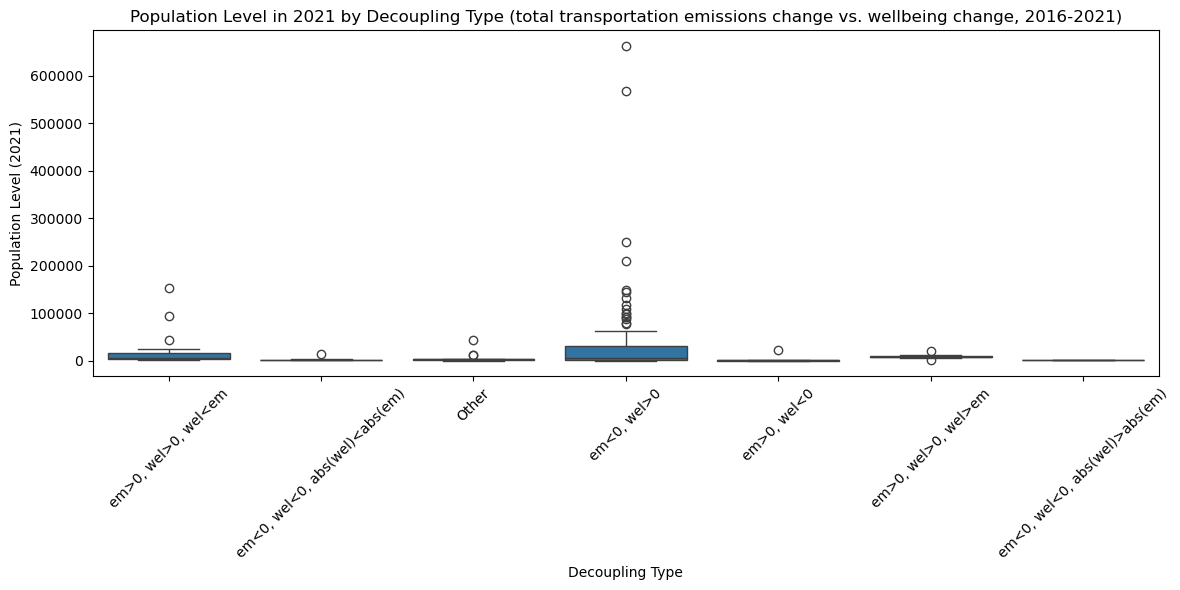

In [73]:
import seaborn as sns

#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='transportation_emissions_decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (total transportation emissions change vs. wellbeing change, 2016-2021)')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

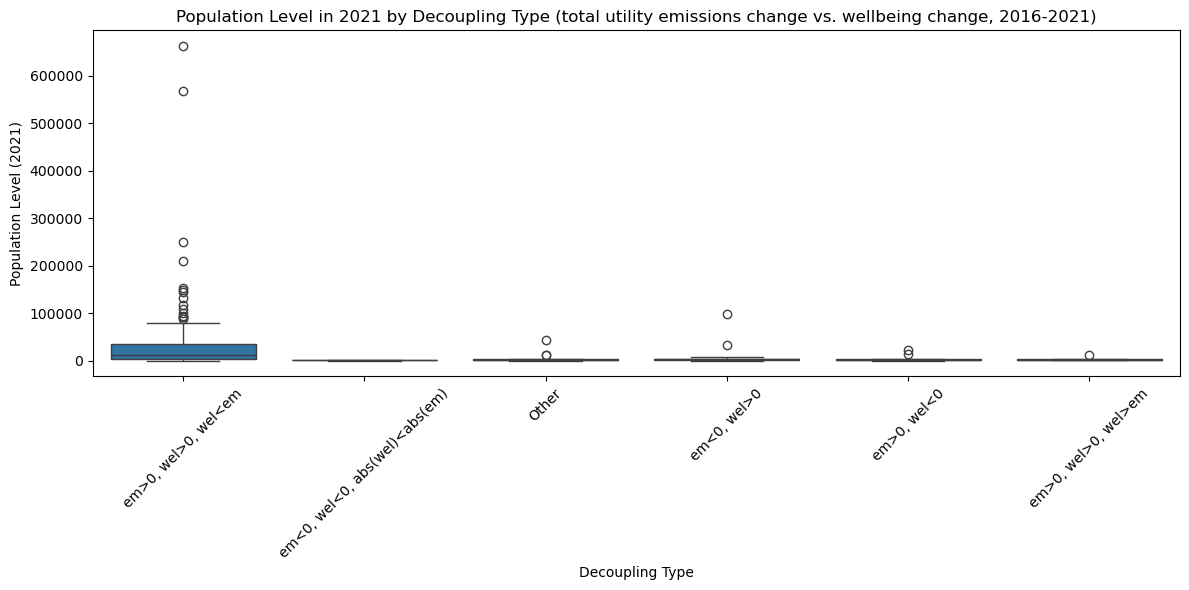

In [77]:

#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='utility_emissions_decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (total utility emissions change vs. wellbeing change, 2016-2021)')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

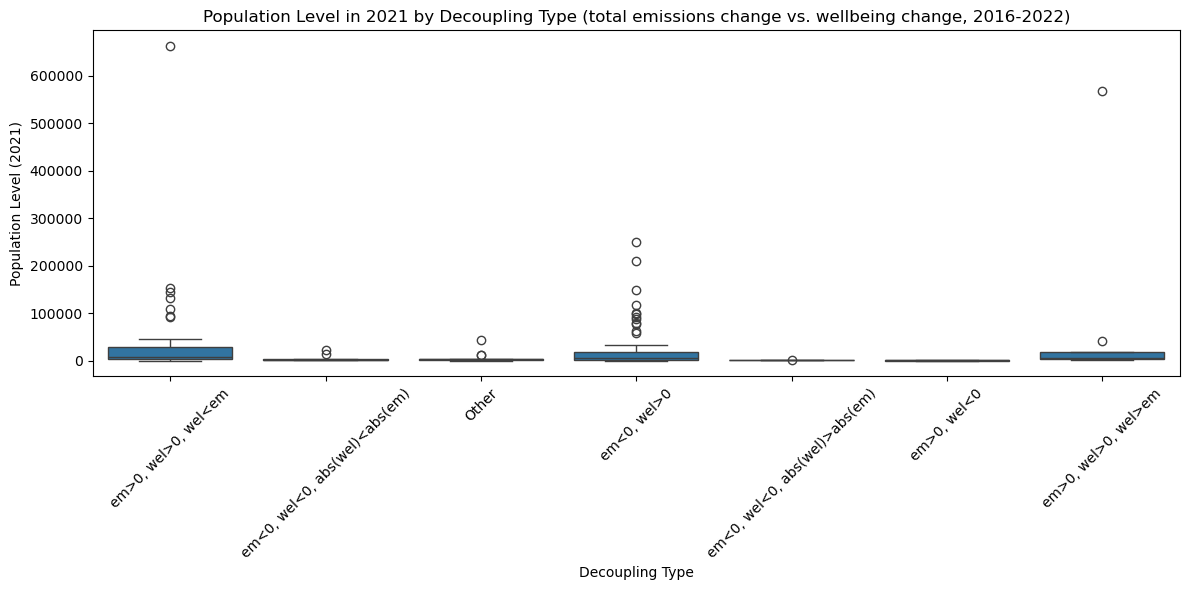

In [52]:
import seaborn as sns

#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='total_emissions_decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (total emissions change vs. wellbeing change, 2016-2022)')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

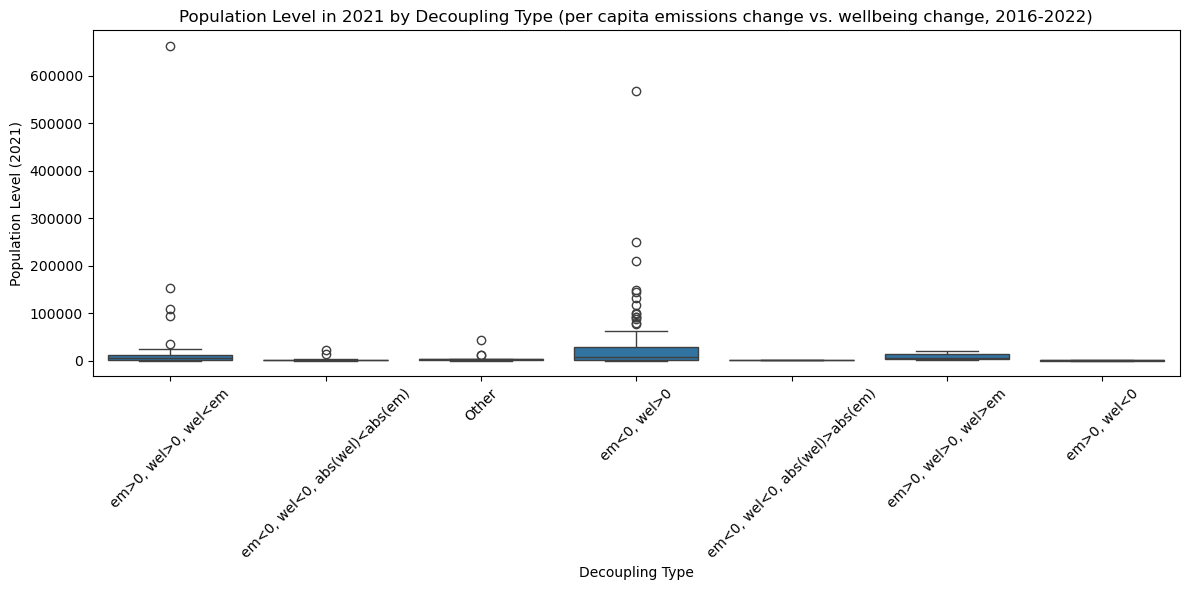

In [57]:
#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='total_emissions_per_capita_decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (per capita emissions change vs. wellbeing change, 2016-2022)')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
#get coordinates of each city in the bc-gazetteer-2024-06-13.csv file in the raw data folder
gazeteer = pd.read_csv(os.path.join('..','data','raw','bc-gazetteer-2024-06-13.csv'))
# Filter for communities in the final analysis data
gazeteer_filtered = gazeteer[gazeteer['Official Name'].isin(final_analysis_data['Community_Name']) & gazeteer['Feature Type'].isin(['City', 'Town', 'District Municipality', 'District Municipality (1)', 'Village (1)','Resort Municipality', 'Mountain Resort Municipality'])]


In [59]:
#print all unique official names in the gazeteer_filtered dataframe
print("Unique official names in gazeteer_filtered:")
print(gazeteer_filtered['Official Name'].unique())
#count unique official names
print(f"Total unique official names in gazeteer_filtered: {gazeteer_filtered['Official Name'].nunique()}")
#figure out which communities are missing coordinates
missing_coordinates = final_analysis_data[~final_analysis_data['Community_Name'].isin(gazeteer_filtered['Official Name'])]
print(f"Communities missing coordinates: {len(missing_coordinates)}")
print("Missing communities:")
for community in missing_coordinates['Community_Name'].unique():
    print(f"  {community}")

Unique official names in gazeteer_filtered:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission' 'Montrose' 'Nakusp'
 'Nanaimo' 'Nelson

In [60]:
# Manual mapping for missing communities using both name and feature type
name_featuretype_corrections = {
    "Langley City": ("Langley", "City"),
    "Langley Township": ("Langley", "District Municipality (1)"),
    "North Vancouver City": ("North Vancouver", "City"),
    "North Vancouver District": ("North Vancouver", "District Municipality (1)"),
    "One Hundred Mile House": ("100 Mile House", "District Municipality (1)"),
    "Sun Peaks Mountain Resort": ("Sun Peaks", "Mountain Resort Municipality"),
    "West Kelowna": ("West Kelowna, City of", "City"),
    "Queen Charlotte": ("Queen Charlotte", "Post Office"),
    "Sechelt IGD": ("Sechelt Indian Government District", "Indian Government District"),
    "Northern Rockies" :("Northern Rockies Regional Municipality","District Municipality (1)") 
}

missing_coords = []
for community, (gaz_name, feature_type) in name_featuretype_corrections.items():
    if feature_type:
        match = gazeteer[(gazeteer['Official Name'].str.lower() == gaz_name.lower()) &
                         (gazeteer['Feature Type'].str.lower() == feature_type.lower())]
    else:
        match = gazeteer[gazeteer['Official Name'].str.lower() == gaz_name.lower()]
    if not match.empty:
        feature_type = match.iloc[0]['Feature Type']
        lat = match.iloc[0]['LatDD']
        lon = match.iloc[0]['LongDD']
        datum = match.iloc[0]['Datum']
        missing_coords.append({'Official Name': community, 'Feature Type': feature_type, 'Datum': datum, 'LatDD': lat, 'LongDD': lon})
    else:
        print(f"Not found in gazeteer: {community} -> {gaz_name} ({feature_type})")

missing_coords_df = pd.DataFrame(missing_coords)
print(missing_coords_df)

               Official Name                  Feature Type  Datum      LatDD  \
0               Langley City                          City  WGS84  49.102500   
1           Langley Township     District Municipality (1)  WGS84  49.120278   
2       North Vancouver City                          City  WGS84  49.320556   
3   North Vancouver District     District Municipality (1)  WGS84  49.336111   
4     One Hundred Mile House     District Municipality (1)  WGS84  51.642778   
5  Sun Peaks Mountain Resort  Mountain Resort Municipality  WGS84  50.884444   
6               West Kelowna                          City  WGS84  49.830000   
7            Queen Charlotte                   Post Office  WGS84  53.253878   
8                Sechelt IGD    Indian Government District  WGS84  49.478960   
9           Northern Rockies     District Municipality (1)  WGS84  58.803889   

       LongDD  
0 -122.658056  
1 -122.659722  
2 -123.073889  
3 -123.078056  
4 -121.295556  
5 -119.879444  
6 -119.

In [ ]:
#add missing communities to gazeteer_filtered
gazeteer_filtered = pd.concat([gazeteer_filtered, missing_coords_df]).reset_index(drop=True)
gazeteer_filtered.head()
#gazeteer_filtered.tail(20)

,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
0,Abbotsford,City,1.0,92G/1,49 03 07 N,122 19 45 W,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),3.0,92L/10,50 35 01 N,126 55 40 W,WGS84,50.583889,-126.927778
2,Anmore,Village (1),3.0,92G/7,49 18 51 N,122 51 23 W,WGS84,49.314444,-122.856389
3,Armstrong,City,1.0,82L/6,50 26 53 N,119 11 48 W,WGS84,50.448333,-119.196667
4,Ashcroft,Village (1),3.0,92I/11,50 43 16 N,121 17 00 W,WGS84,50.721389,-121.283611


In [62]:
gazeteer_filtered.tail(20)

,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
141,Vernon,City,1.0,82L/6,50 15 56 N,119 16 18 W,WGS84,50.265833,-119.271667
142,Victoria,City,1.0,92B/6,48 25 41 N,123 21 52 W,WGS84,48.428333,-123.364722
143,View Royal,Town,2.0,92B/6,48 27 06 N,123 26 03 W,WGS84,48.451944,-123.434167
144,Warfield,Village (1),3.0,82F/4,49 05 38 N,117 44 57 W,WGS84,49.094167,-117.749167
145,Wells,District Municipality (1),35.0,93H/4,53 06 15 N,121 34 21 W,WGS84,53.104444,-121.572500
146,West Vancouver,District Municipality (1),35.0,92G/6,49 19 51 N,123 09 34 W,WGS84,49.331111,-123.159722
147,Whistler,Resort Municipality,16.0,92J/2,50 07 01 N,122 57 16 W,WGS84,50.117222,-122.954722
148,White Rock,City,1.0,92G/2,49 01 24 N,122 47 53 W,WGS84,49.023611,-122.798333
149,Williams Lake,City,1.0,93B/1,52 07 44 N,122 08 24 W,WGS84,52.129167,-122.140000
150,Zeballos,Village (1),3.0,92E/15,49 58 56 N,126 50 45 W,WGS84,49.982500,-126.846111


In [63]:
#check if the gazeteer_filtered dataframe has all the communities from final_analysis_data
print(f"Total communities in final_analysis_data: {len(final_analysis_data['Community_Name'].unique())}")
print(f"Total communities in gazeteer_filtered: {len(gazeteer_filtered['Official Name'].unique())}")
missing_communities =  set(gazeteer_filtered['Official Name'].unique()) - set(final_analysis_data['Community_Name'].unique())
print(f"Missing communities in gazeteer_filtered: {len(missing_communities)}")
if missing_communities:
    print("Missing communities:")
    for community in missing_communities:
        print(f"  {community}")

Total communities in final_analysis_data: 161
Total communities in gazeteer_filtered: 161
Missing communities in gazeteer_filtered: 0


In [64]:
#find duplicates
duplicates = gazeteer_filtered[gazeteer_filtered.duplicated(subset=['Official Name'], keep=False)]
print(f"Total duplicates found: {len(duplicates)}")
if not duplicates.empty:
    print("Duplicate entries:")
    for index, row in duplicates.iterrows():
        print(f"  {row['Official Name']} (Index: {index})")


Total duplicates found: 0


In [65]:
#extract official name, feature type, datum, latitude and longitude from gazeteer_filtered
gazeteer_final = gazeteer_filtered[['Official Name', 'Feature Type', 'Datum', 'LatDD', 'LongDD']].copy()
gazeteer_final.rename(columns={
    'Official Name': 'Community_Name',
    'Feature Type': 'Feature_Type',
    'Datum': 'Datum',
    'LatDD': 'Latitude',
    'LongDD': 'Longitude'
}, inplace=True)
# Save the gazeteer_final dataframe to a CSV file in the processed data folder
gazeteer_final.to_csv(os.path.join('..', 'data', 'processed', 'gazeteer_final.csv'), index=False)

In [71]:
gazeteer_final.head(20)

,Community_Name,Feature_Type,Datum,Latitude,Longitude
0,Abbotsford,City,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),WGS84,50.583889,-126.927778
2,Anmore,Village (1),WGS84,49.314444,-122.856389
3,Armstrong,City,WGS84,50.448333,-119.196667
4,Ashcroft,Village (1),WGS84,50.721389,-121.283611
5,Barriere,District Municipality (1),WGS84,51.179722,-120.123611
6,Belcarra,Village (1),WGS84,49.313611,-122.915000
7,Bowen Island,District Municipality (1),WGS84,49.379722,-123.344167
8,Burnaby,City,WGS84,49.242778,-122.972778
9,Burns Lake,Village (1),WGS84,54.230278,-125.764444


In [67]:
#merge the gazeteer data with the final_analysis_data
final_analysis_data_with_coords = pd.merge(final_analysis_data, gazeteer_final, on='Community_Name')
# Save the final analysis data with coordinates to a CSV file in the processed data folder
final_analysis_data_with_coords.to_csv(os.path.join('..', 'data', 'processed', 'final_analysis_data_with_coords.csv'), index=False)
# Display the final analysis data with coordinates
print("Final analysis data with coordinates:")
print(final_analysis_data_with_coords.head())

Final analysis data with coordinates:
  Community_Name  2016 total emissions tCO2e  2021 total emissions tCO2e  \
0     Abbotsford               926180.582000                1.045921e+06   
1      Alert Bay                 1602.705601                1.271113e+03   
2         Anmore                11972.111512                1.134648e+04   
3      Armstrong                36938.412983                3.417424e+04   
4       Ashcroft                19076.397754                1.899236e+04   

   total_emissions_percent_change  2016 transportation emissions tCO2e  \
0                       12.928395                        569263.582000   
1                      -20.689535                          1194.705601   
2                       -5.225766                          7421.111512   
3                       -7.483200                         26823.412983   
4                       -0.440552                          6743.397754   

   2021 transportation emissions tCO2e  \
0                 

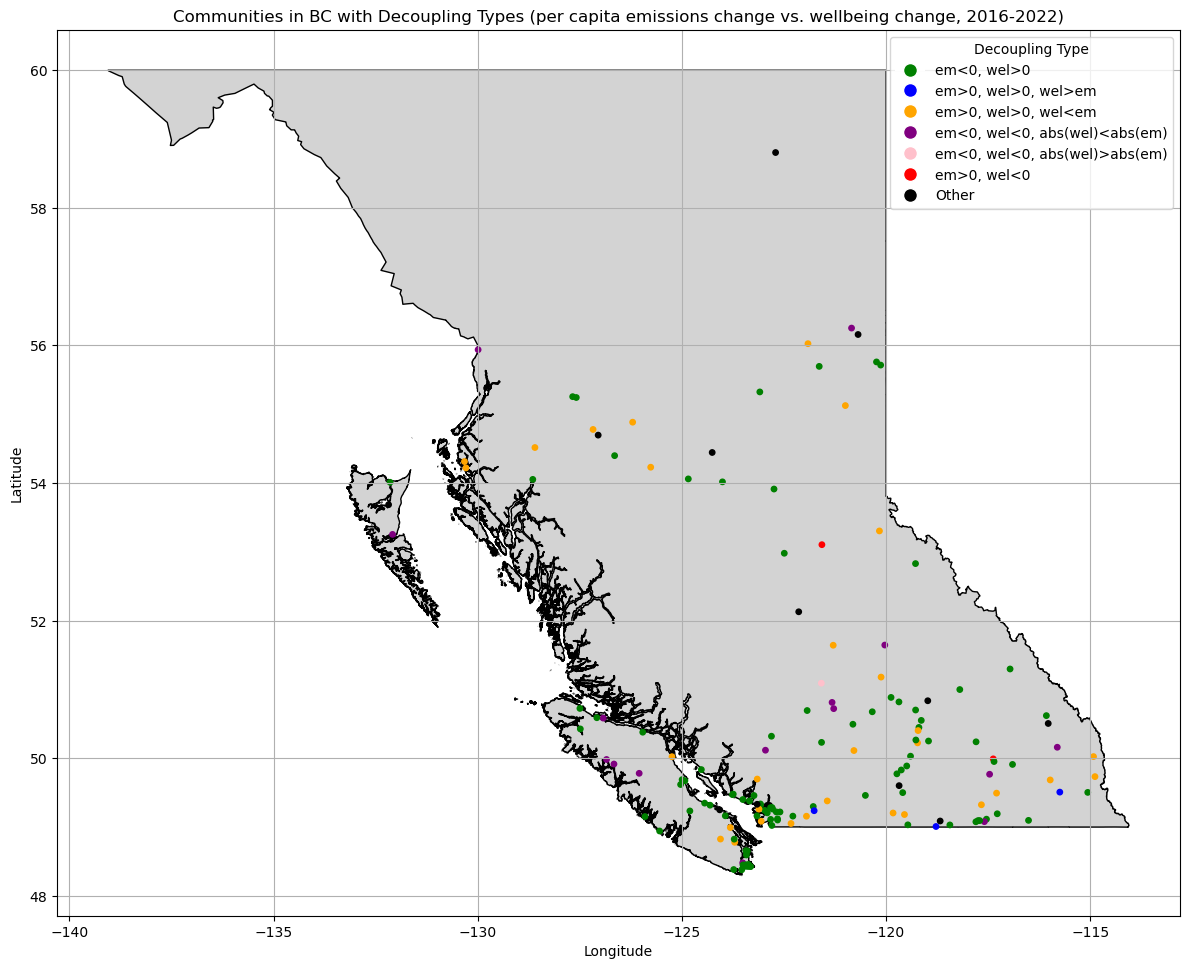

In [69]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    final_analysis_data_with_coords,
    geometry=gpd.points_from_xy(final_analysis_data_with_coords['Longitude'], final_analysis_data_with_coords['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)

decoupling_colors = {
    'em<0, wel>0': 'green',
    'em>0, wel>0, wel>em': 'blue',
    'em>0, wel>0, wel<em': 'orange',
    'em<0, wel<0, abs(wel)<abs(em)': 'purple',
    'em<0, wel<0, abs(wel)>abs(em)': 'pink',
    'em>0, wel<0': 'red',
    'Other': 'black'  # Default color for any other cases
}

final_analysis_gdf['color'] = final_analysis_gdf['total_emissions_per_capita_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (per capita emissions change vs. wellbeing change, 2016-2022)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

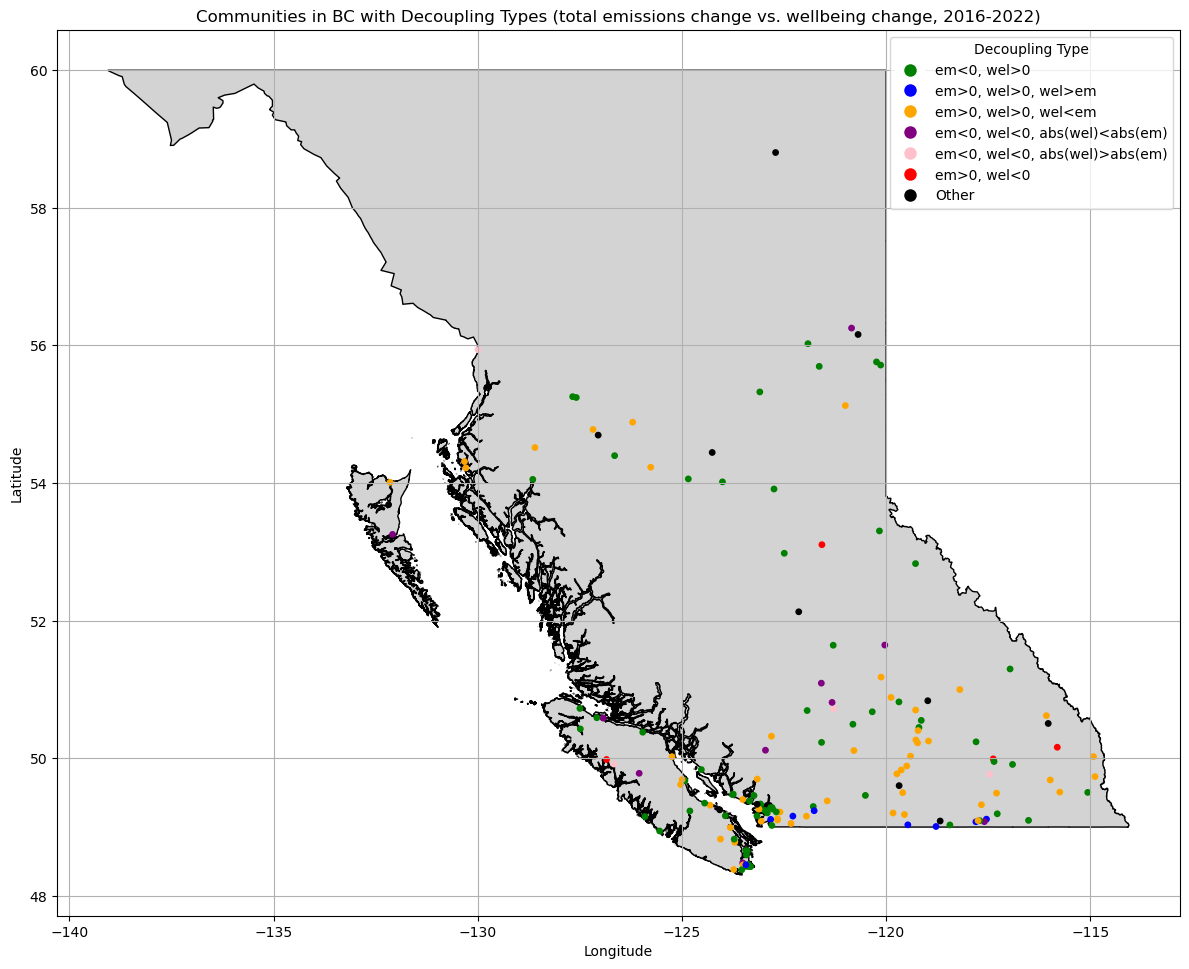

In [70]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    final_analysis_data_with_coords,
    geometry=gpd.points_from_xy(final_analysis_data_with_coords['Longitude'], final_analysis_data_with_coords['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)

decoupling_colors = {
    'em<0, wel>0': 'green',
    'em>0, wel>0, wel>em': 'blue',
    'em>0, wel>0, wel<em': 'orange',
    'em<0, wel<0, abs(wel)<abs(em)': 'purple',
    'em<0, wel<0, abs(wel)>abs(em)': 'pink',
    'em>0, wel<0': 'red',
    'Other': 'black'  # Default color for any other cases
}

final_analysis_gdf['color'] = final_analysis_gdf['total_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (total emissions change vs. wellbeing change, 2016-2022)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Find name of communities in the worse case scenario
worse_case_communities = final_analysis_gdf[final_analysis_gdf['decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Community_Name'])


12     Canal Flats
83      New Denver
154          Wells
160       Zeballos
Name: Community_Name, dtype: object


In [75]:
# Find name of communities in the worse case scenario
worse_case_communities = final_analysis_gdf[final_analysis_gdf['transportation_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Community_Name'], worse_case_communities['transportation_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['population_2021'])


KeyError: 'population_2021'

Next steps:
1) Manually create municipal shapefile boundaries for the municipalities that are missing from the data
2) Find if there is a way to include Northern Rockies
3) decide to include seachelt IDG or exclude it
4) add emissions of facilities outside of municipal boundaries to nearest municipality 




1) (DONE) map the coupling vs decoupling of municipalities across BC
    a) (DONE) find coordinates of each municipality
2) (DONE) add transportation emissions to building emissions and redo analysis
    a) show road networks in the map and power line networks as well
3) segregate analysis by sector (industry vs residential)
4) try using emissions from 2007 with wellbeing from 2006?
5) compare the disaggregated components of the wellbeing index (e.g. income vs. education vs. housing) with the emissions 
6) compare coupling/decoupling with climate action plans in LGCAP and with climate impacts to see which communities are most vulnerable
7) use actual census data (e.g. mean income value for community, education level) and make a random forest model that predicts coupling/decoupling using the census data?
8) see if the poorest communities that had lowest wellbeing to start with are the ones going through negative decoupling
9) subtract wellbeing change from emissions change to have a number that measures the extent of decoupling, or use taipa equation
